<a href="https://colab.research.google.com/github/ishanwa/Forecasting_project/blob/main/CatBoost/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [3]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [4]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100


Processing: RevenueCenter_1


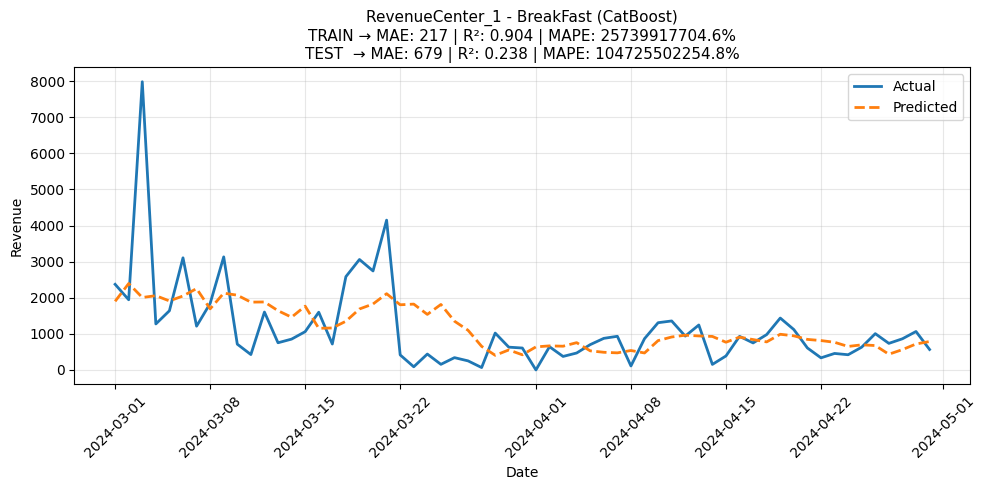

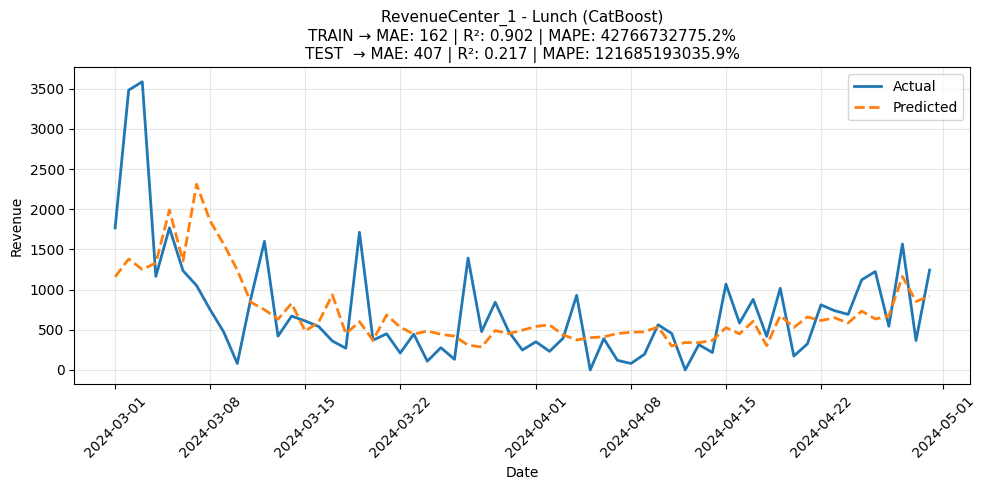

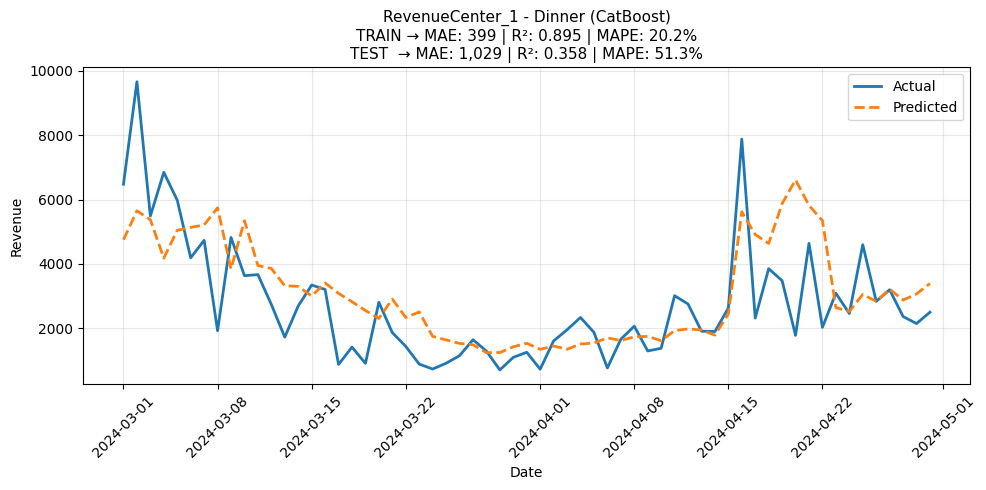

Saved CatBoost results → /content/RevenueCenter_1

Processing: RevenueCenter_9


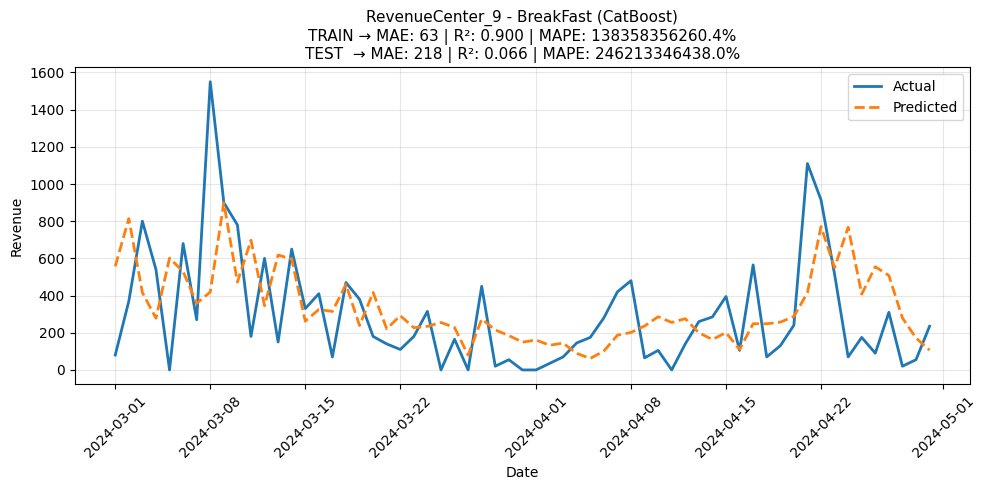

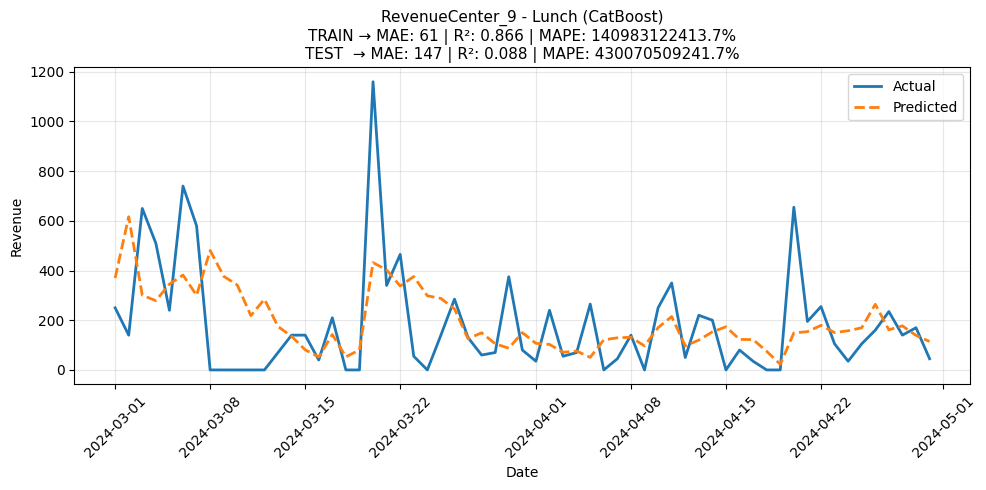

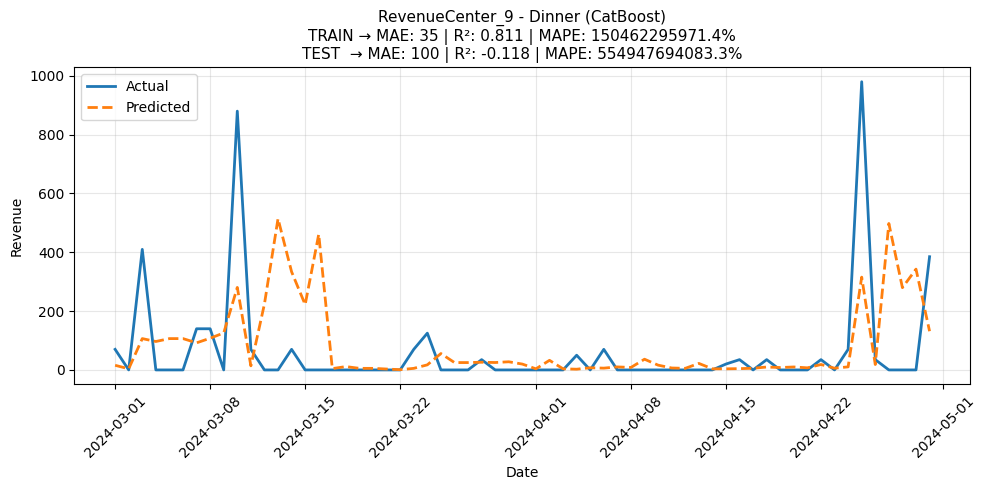

Saved CatBoost results → /content/RevenueCenter_9

Processing: RevenueCenter_2


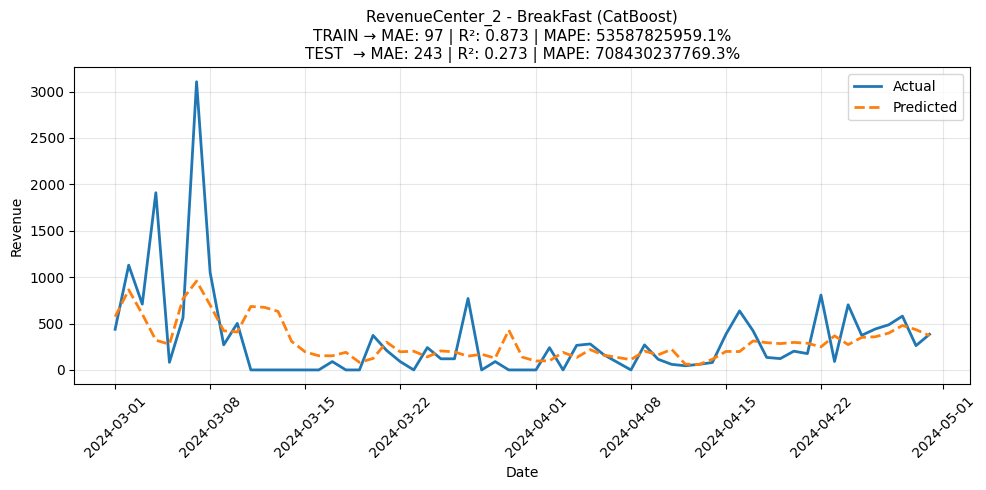

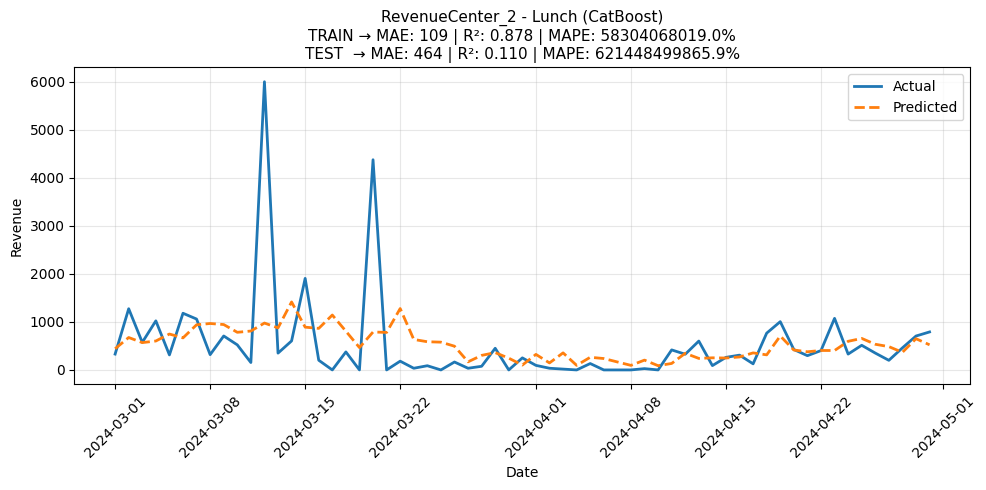

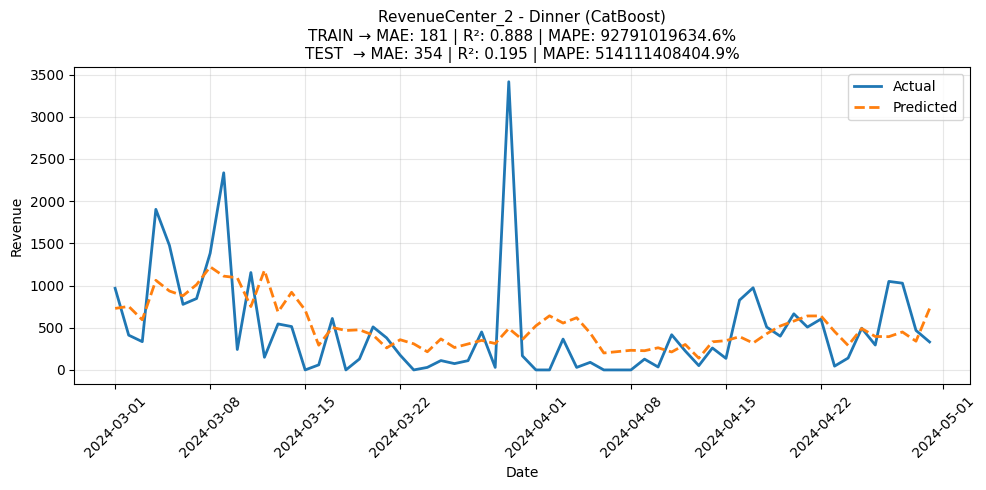

Saved CatBoost results → /content/RevenueCenter_2

Processing: RevenueCenter_7


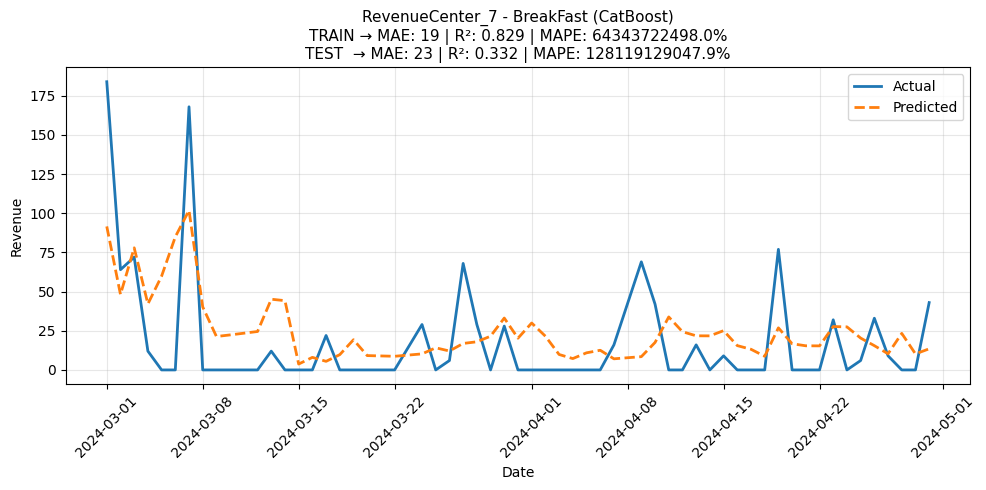

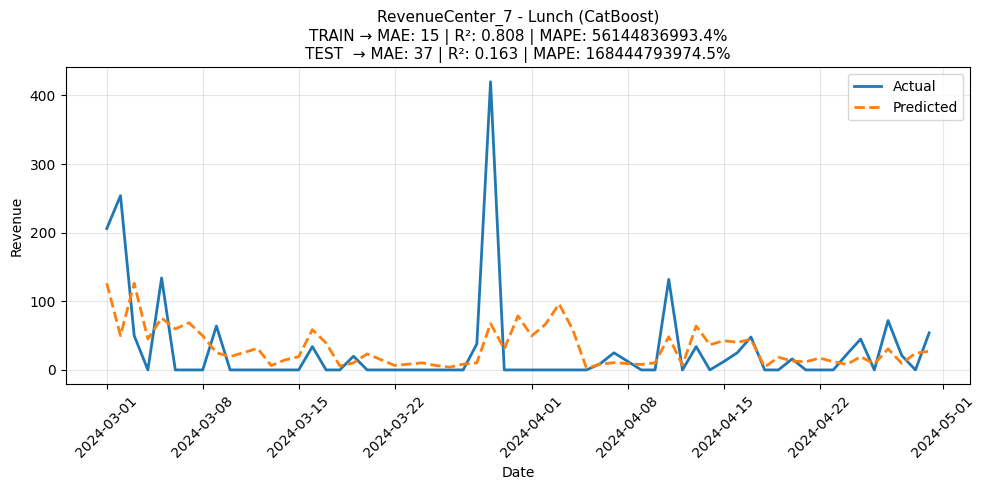

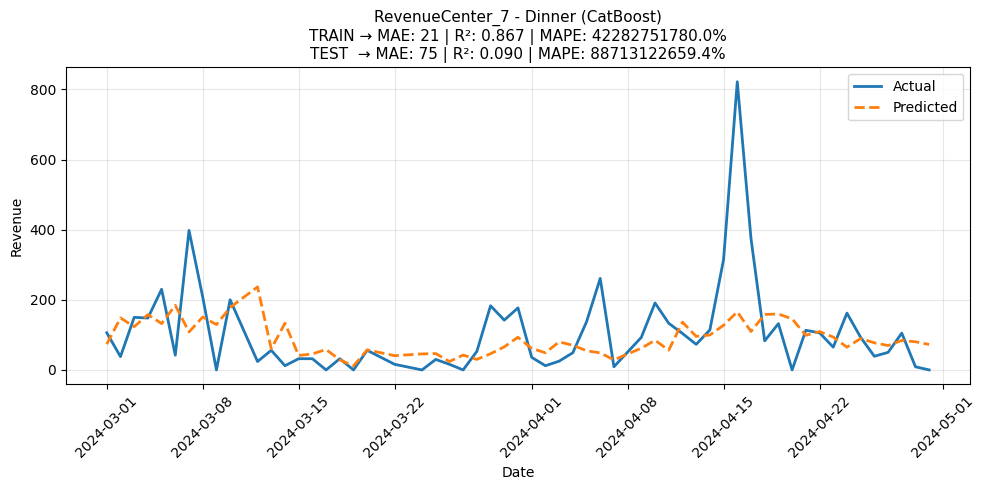

Saved CatBoost results → /content/RevenueCenter_7

Processing: RevenueCenter_5


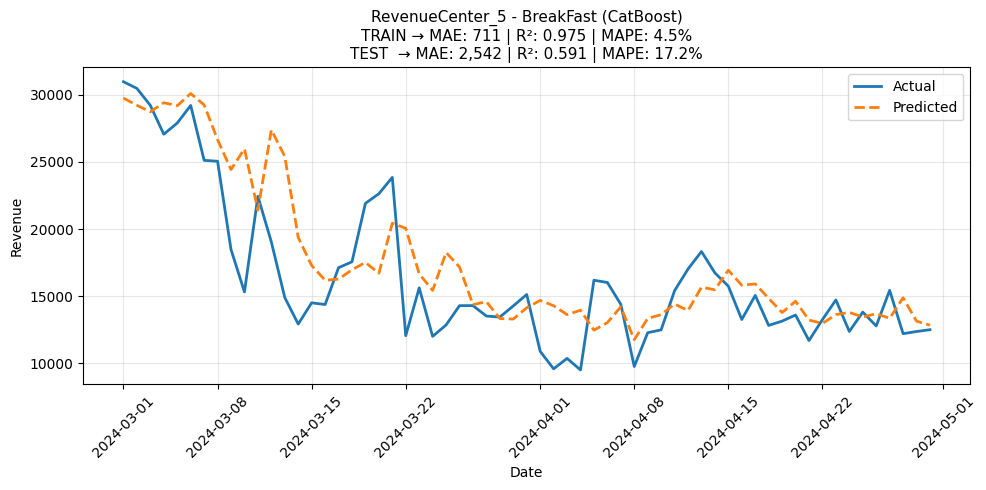

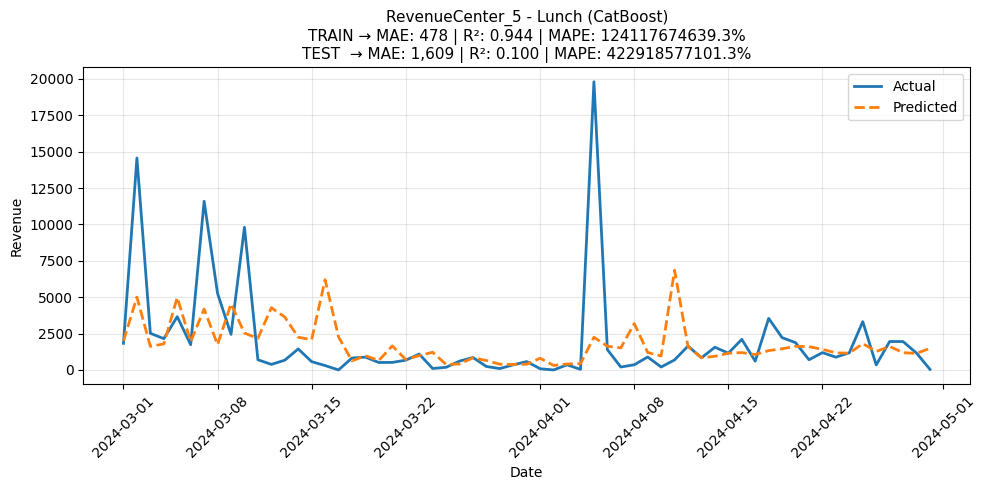

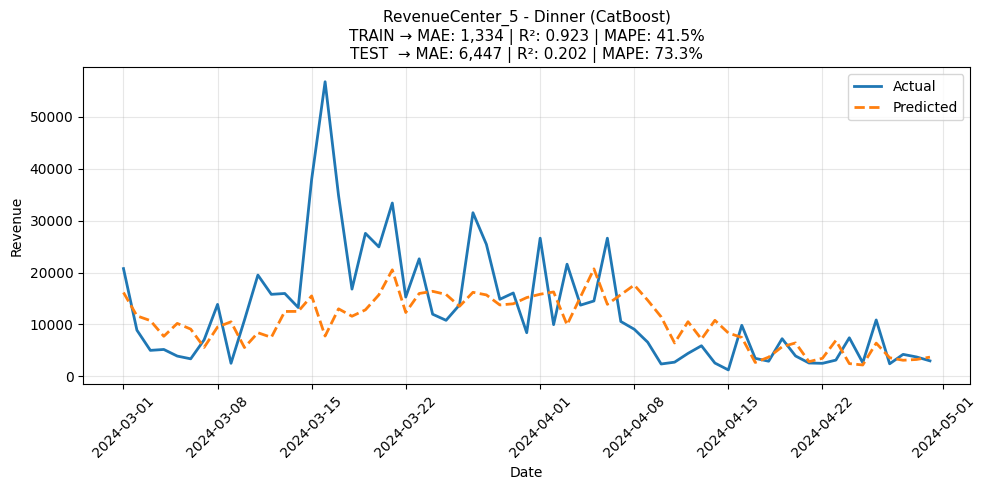

Saved CatBoost results → /content/RevenueCenter_5

Processing: RevenueCenter_4
 Skipping RevenueCenter_4 - BreakFast: target is constant
 Skipping RevenueCenter_4 - Lunch: target is constant


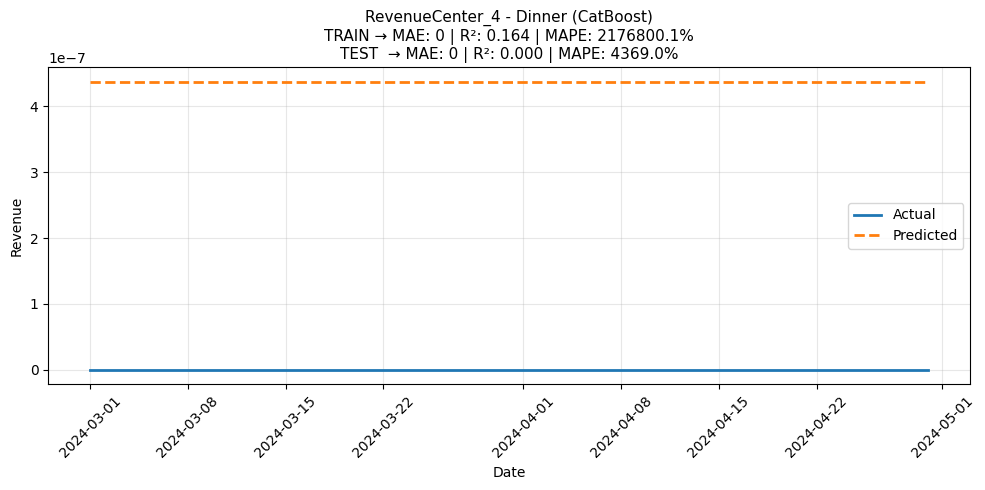

Saved CatBoost results → /content/RevenueCenter_4

Processing: RevenueCenter_3


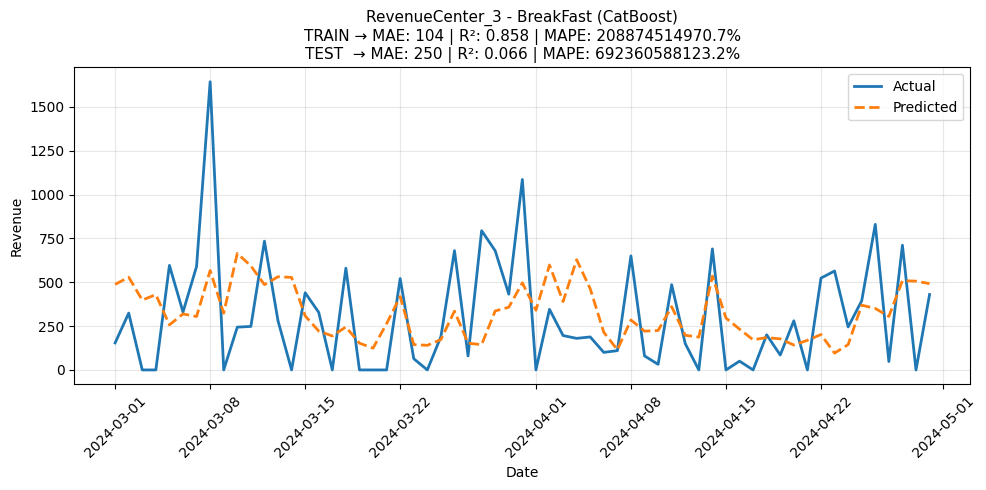

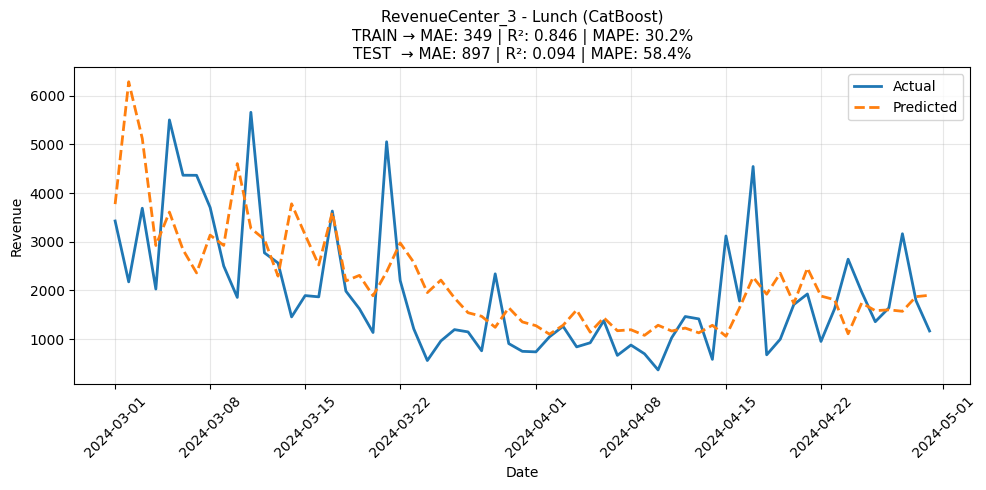

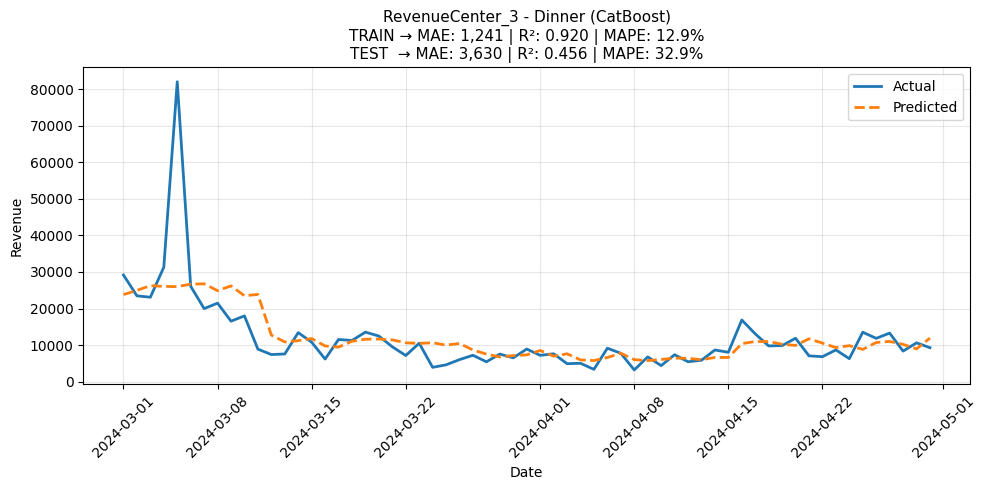

Saved CatBoost results → /content/RevenueCenter_3

Processing: RevenueCenter_8


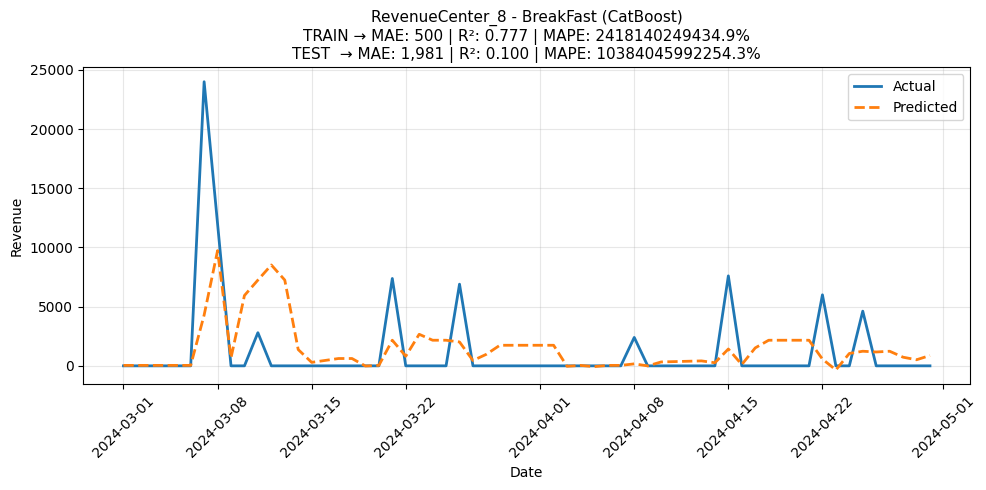

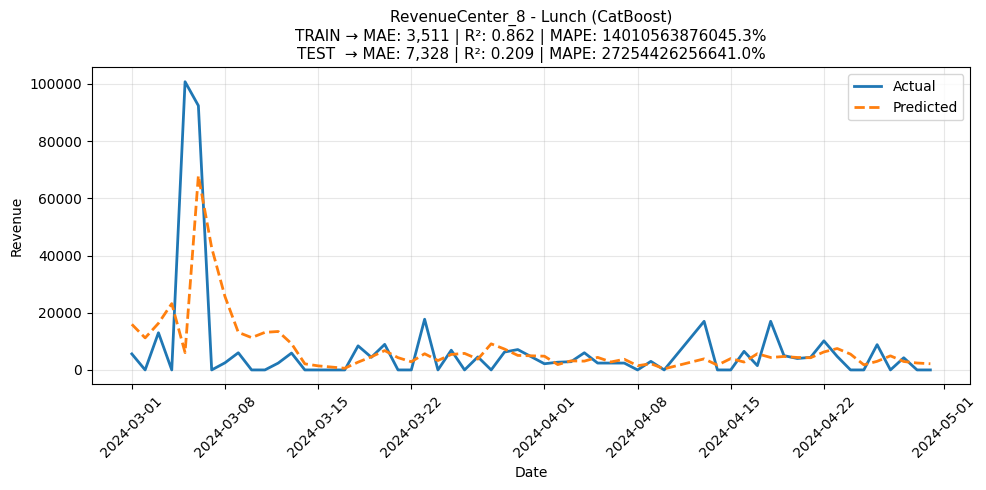

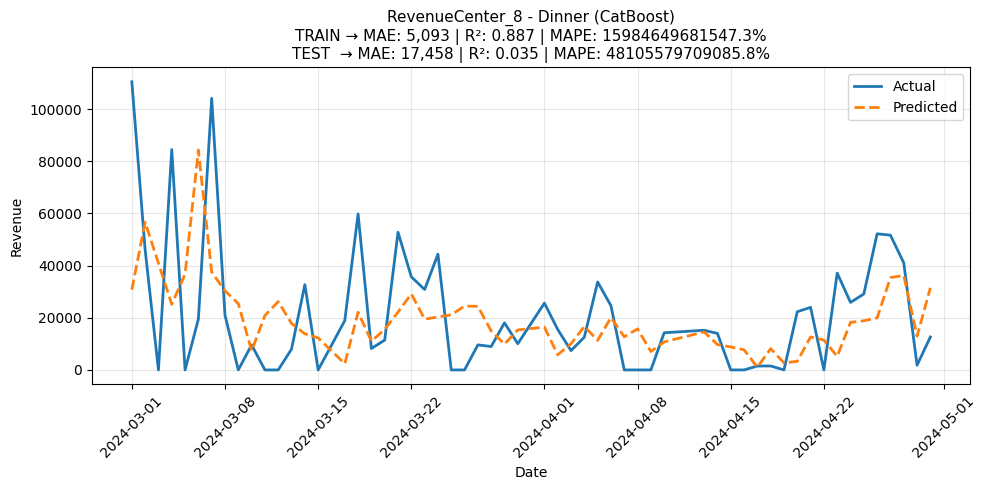

Saved CatBoost results → /content/RevenueCenter_8

Processing: RevenueCenter_6


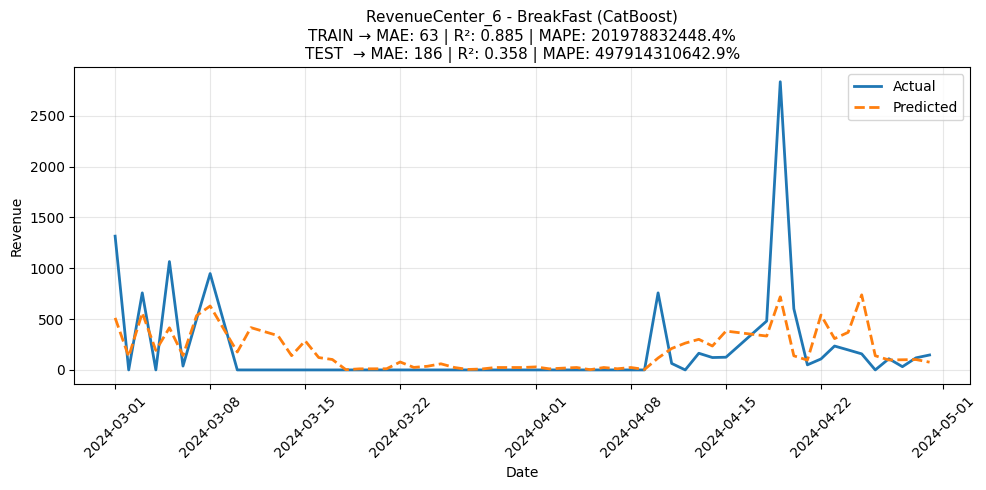

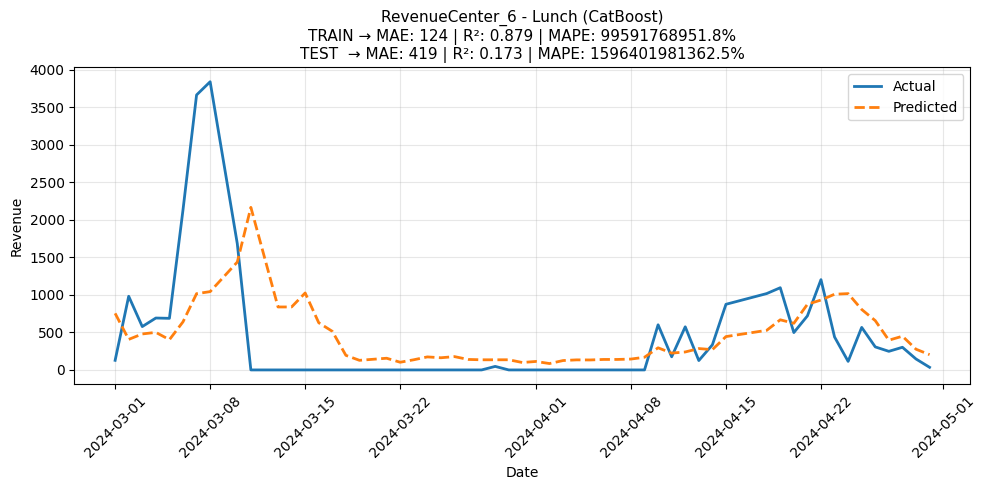

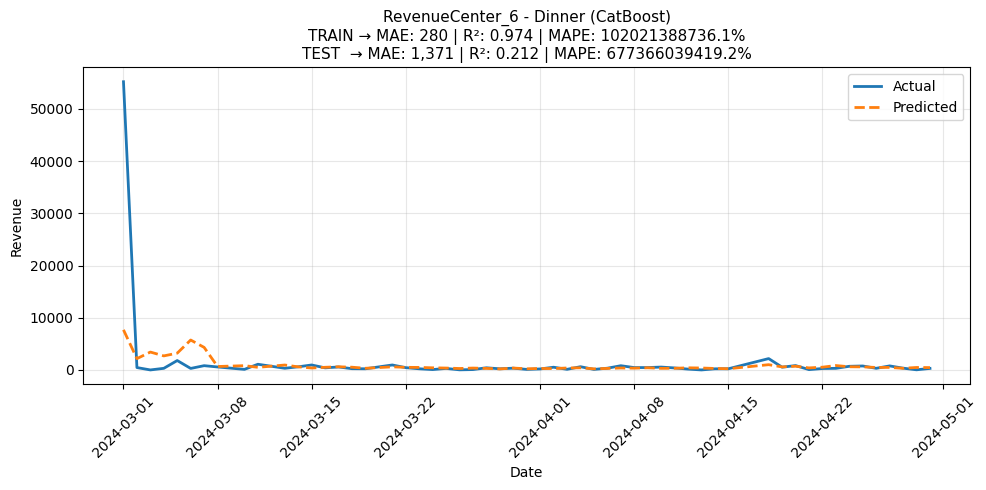

Saved CatBoost results → /content/RevenueCenter_6

ALL REVENUE CENTERS COMPLETED (CATBOOST)


In [5]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    # Last 2 months as test set
    split_date = df["Date"].max() - pd.DateOffset(months=2)

    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        # Prepare meal-specific dataset
        temp_df = df[["Date", meal]].copy()
        temp_df.rename(columns={meal: "y"}, inplace=True)

        # Lag features
        temp_df["lag_1"]  = temp_df["y"].shift(1)
        temp_df["lag_7"]  = temp_df["y"].shift(7)
        temp_df["lag_14"] = temp_df["y"].shift(14)
        temp_df["lag_30"] = temp_df["y"].shift(30)

        # Rolling statistics
        temp_df["roll_mean_7"] = temp_df["y"].rolling(7).mean()
        temp_df["roll_std_7"]  = temp_df["y"].rolling(7).std()

        # Remove rows with NaN
        temp_df.dropna(inplace=True)

        # Train / Test split
        train_df = temp_df[temp_df["Date"] <= split_date]
        test_df  = temp_df[temp_df["Date"] > split_date]

        X_train = train_df.drop(["Date", "y"], axis=1)
        y_train = train_df["y"]

        X_test = test_df.drop(["Date", "y"], axis=1)
        y_test = test_df["y"]

        test_dates = test_df["Date"]


        # Skip if training target is constant
        # (avoids CatBoostError)

        if y_train.nunique() == 1:
            print(f" Skipping {center_name} - {meal}: target is constant")
            continue

        # CatBoost model
        model = CatBoostRegressor(
            iterations=100,
            learning_rate=0.1,
            depth=8,
            loss_function="RMSE",
            random_seed=42,
            verbose=0
        )

        # Train model
        model.fit(X_train, y_train)

        # Predictions

        y_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)

        # TRAIN METRICS
        train_mae  = mean_absolute_error(y_train, y_train_pred)
        train_r2   = r2_score(y_train, y_train_pred)
        train_mape = mape(y_train, y_train_pred)

        # TEST METRICS
        test_mae  = mean_absolute_error(y_test, y_pred)
        test_r2   = r2_score(y_test, y_pred)
        test_mape = mape(y_test, y_pred)

        # Plot Actual vs Predicted
        plt.figure(figsize=(10, 5))

        plt.plot(test_dates, y_test, label="Actual", linewidth=2)
        plt.plot(test_dates, y_pred, "--", label="Predicted", linewidth=2)

        plt.title(
            f"{center_name} - {meal} (CatBoost)\n"
            f"TRAIN → MAE: {train_mae:,.0f} | R²: {train_r2:.3f} | MAPE: {train_mape:.1f}%\n"
            f"TEST  → MAE: {test_mae:,.0f} | R²: {test_r2:.3f} | MAPE: {test_mape:.1f}%",
            fontsize=11
        )

        plt.xlabel("Date")
        plt.ylabel("Revenue")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()

        plt.show()
        plt.close()

    print(f"Saved CatBoost results → {center_path}")

print("\nALL REVENUE CENTERS COMPLETED (CATBOOST)")

In [6]:
y_min = y_train.min()
y_max = y_train.max()

print("Target range:", y_min, "to", y_max)
print("Range width:", y_max - y_min)

Target range: 0.0 to 37870.0
Range width: 37870.0
